In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [129]:
data = pd.read_csv("data/car_price.csv")
data.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [130]:
data.isna().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [131]:
data.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [132]:
X = data.drop(columns=['car_ID', 'symboling', 'price'])
y = data['price']


In [133]:
X.columns

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'peakrpm', 'citympg', 'highwaympg'],
      dtype='object')

In [134]:
X.nunique()

CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
dtype: int64

In [135]:
X['cylindernumber'].unique()

array(['four', 'six', 'five', 'three', 'twelve', 'two', 'eight'],
      dtype=object)

In [136]:
X['doornumber'].unique()

array(['two', 'four'], dtype=object)

In [137]:
cylinder_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

X['cylindernumber'] = X['cylindernumber'].map(cylinder_map)

X['cylindernumber']

0      4
1      4
2      6
3      4
4      5
      ..
200    4
201    4
202    6
203    6
204    4
Name: cylindernumber, Length: 205, dtype: int64

In [138]:
X['doornumber'] = X['doornumber'].map(cylinder_map)
X['doornumber']

0      2
1      2
2      2
3      4
4      4
      ..
200    4
201    4
202    4
203    4
204    4
Name: doornumber, Length: 205, dtype: int64

In [139]:
X.select_dtypes(include=['int64', 'float64']).columns, X.select_dtypes(exclude=['int64', 'float64']).columns

(Index(['doornumber', 'wheelbase', 'carlength', 'carwidth', 'carheight',
        'curbweight', 'cylindernumber', 'enginesize', 'boreratio', 'stroke',
        'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg'],
       dtype='object'),
 Index(['CarName', 'fueltype', 'aspiration', 'carbody', 'drivewheel',
        'enginelocation', 'enginetype', 'fuelsystem'],
       dtype='object'))

In [140]:
X

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
0,alfa-romero giulia,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27
1,alfa-romero stelvio,gas,std,2,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,4,130,mpfi,3.47,2.68,9.0,111,5000,21,27
2,alfa-romero Quadrifoglio,gas,std,2,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,6,152,mpfi,2.68,3.47,9.0,154,5000,19,26
3,audi 100 ls,gas,std,4,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,4,109,mpfi,3.19,3.40,10.0,102,5500,24,30
4,audi 100ls,gas,std,4,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,5,136,mpfi,3.19,3.40,8.0,115,5500,18,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,volvo 145e (sw),gas,std,4,sedan,rwd,front,109.1,188.8,68.9,55.5,2952,ohc,4,141,mpfi,3.78,3.15,9.5,114,5400,23,28
201,volvo 144ea,gas,turbo,4,sedan,rwd,front,109.1,188.8,68.8,55.5,3049,ohc,4,141,mpfi,3.78,3.15,8.7,160,5300,19,25
202,volvo 244dl,gas,std,4,sedan,rwd,front,109.1,188.8,68.9,55.5,3012,ohcv,6,173,mpfi,3.58,2.87,8.8,134,5500,18,23
203,volvo 246,diesel,turbo,4,sedan,rwd,front,109.1,188.8,68.9,55.5,3217,ohc,6,145,idi,3.01,3.40,23.0,106,4800,26,27


			doornumber				wheelbase	carlength	carwidth	carheight	curbweight		cylindernumber	enginesize		boreratio	stroke	compressionratio	horsepower	peakrpm	citympg	highwaympg

In [141]:
cat_columns = ['CarName', 'fueltype', 'aspiration', 'carbody', 'drivewheel',
                'enginelocation', 'enginetype', 'fuelsystem']

In [142]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False)

car_names = enc.fit_transform(data[cat_columns])
car_names_df = pd.DataFrame(car_names, columns=enc.get_feature_names_out(cat_columns))

X = X.drop(columns=cat_columns, axis=1)
X = pd.concat([X.reset_index(drop=True), car_names_df.reset_index(drop=True)], axis=1)
X


,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,CarName_Nissan versa,CarName_alfa-romero Quadrifoglio,CarName_alfa-romero giulia,CarName_alfa-romero stelvio,CarName_audi 100 ls,CarName_audi 100ls,CarName_audi 4000,CarName_audi 5000,CarName_audi 5000s (diesel),CarName_audi fox,CarName_bmw 320i,CarName_bmw x1,CarName_bmw x3,CarName_bmw x4,CarName_bmw x5,CarName_bmw z4,CarName_buick century,CarName_buick century luxus (sw),CarName_buick century special,CarName_buick electra 225 custom,CarName_buick opel isuzu deluxe,CarName_buick regal sport coupe (turbo),CarName_buick skyhawk,CarName_buick skylark,CarName_chevrolet impala,...,CarName_volkswagen super beetle,CarName_volkswagen type 3,CarName_volvo 144ea,CarName_volvo 145e (sw),CarName_volvo 244dl,CarName_volvo 245,CarName_volvo 246,CarName_volvo 264gl,CarName_volvo diesel,CarName_vw dasher,CarName_vw rabbit,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginelocation_front,enginelocation_rear,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111,5000,21,27,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,88.6,168.8,64.1,48.8,2548,4,130,3.47,2.68,9.0,111,5000,21,27,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,94.5,171.2,65.5,52.4,2823,6,152,2.68,3.47,9.0,154,5000,19,26,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,99.8,176.6,66.2,54.3,2337,4,109,3.19,3.40,10.0,102,5500,24,30,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,99.4,176.6,66.4,54.3,2824,5,136,3.19,3.40,8.0,115,5500,18,22,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,4,109.1,188.8,68.9,55.5,2952,4,141,3.78,3.15,9.5,114,5400,23,28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
201,4,109.1,188.8,68.8,55.5,3049,4,141,3.78,3.15,8.7,160,5300,19,25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.

In [143]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [144]:
X_train.shape, y_train.shape, y_test.shape

((164, 191), (164,), (41,))

In [159]:
X_train.head()

,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,CarName_Nissan versa,CarName_alfa-romero Quadrifoglio,CarName_alfa-romero giulia,CarName_alfa-romero stelvio,CarName_audi 100 ls,CarName_audi 100ls,CarName_audi 4000,CarName_audi 5000,CarName_audi 5000s (diesel),CarName_audi fox,CarName_bmw 320i,CarName_bmw x1,CarName_bmw x3,CarName_bmw x4,CarName_bmw x5,CarName_bmw z4,CarName_buick century,CarName_buick century luxus (sw),CarName_buick century special,CarName_buick electra 225 custom,CarName_buick opel isuzu deluxe,CarName_buick regal sport coupe (turbo),CarName_buick skyhawk,CarName_buick skylark,CarName_chevrolet impala,...,CarName_volkswagen super beetle,CarName_volkswagen type 3,CarName_volvo 144ea,CarName_volvo 145e (sw),CarName_volvo 244dl,CarName_volvo 245,CarName_volvo 246,CarName_volvo 264gl,CarName_volvo diesel,CarName_vw dasher,CarName_vw rabbit,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginelocation_front,enginelocation_rear,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
66,4,104.9,175.0,66.1,54.4,2700,4,134,3.43,3.64,22.0,72,4200,31,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
111,4,107.9,186.7,68.4,56.7,3075,4,120,3.46,2.19,8.4,95,5000,19,24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
153,4,95.7,169.7,63.6,59.1,2280,4,92,3.05,3.03,9.0,62,4800,31,37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
96,4,94.5,165.3,63.8,54.5,1971,4,97,3.15,3.29,9.4,69,5200,31,37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
38,2,96.5,167.5,65.2,53.3,2289,4,110,3.15,3.58,9.0,86,5800,27,33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [157]:
X_train.describe()

,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,CarName_Nissan versa,CarName_alfa-romero Quadrifoglio,CarName_alfa-romero giulia,CarName_alfa-romero stelvio,CarName_audi 100 ls,CarName_audi 100ls,CarName_audi 4000,CarName_audi 5000,CarName_audi 5000s (diesel),CarName_audi fox,CarName_bmw 320i,CarName_bmw x1,CarName_bmw x3,CarName_bmw x4,CarName_bmw x5,CarName_bmw z4,CarName_buick century,CarName_buick century luxus (sw),CarName_buick century special,CarName_buick electra 225 custom,CarName_buick opel isuzu deluxe,CarName_buick regal sport coupe (turbo),CarName_buick skyhawk,CarName_buick skylark,CarName_chevrolet impala,...,CarName_volkswagen super beetle,CarName_volkswagen type 3,CarName_volvo 144ea,CarName_volvo 145e (sw),CarName_volvo 244dl,CarName_volvo 245,CarName_volvo 246,CarName_volvo 264gl,CarName_volvo diesel,CarName_vw dasher,CarName_vw rabbit,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginelocation_front,enginelocation_rear,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
count,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.0,164.000000,164.000000,164.000000,164.000000,164.0,164.0,164.000000,164.0,164.0,164.0,164.0,164.000000,164.000000,164.000000,164.000000,164.0,...,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,3.085366,98.728659,174.127439,65.922561,53.715854,2556.439024,4.390244,126.414634,3.320854,3.254909,10.089085,104.701220,5144.207317,25.073171,30.573171,0.006098,0.006098,0.006098,0.006098,0.006098,0.012195,0.006098,0.006098,0.0,0.006098,0.012195,0.006098,0.012195,0.0,0.0,0.006098,0.0,0.0,0.0,0.0,0.006098,0.006098,0.006098,0.006098,0.0,...,0.006098,0.006098,0.006098,0.006098,0.006098,0.006098,0.006098,0.012195,0.006098,0.006098,0.006098,0.091463,0.908537,0.823171,0.176829,0.036585,0.030488,0.341463,0.475610,0.115854,0.036585,0.579268,0.384146,0.981707,0.018293,0.073171,0.006098,0.067073,0.707317,0.067073,0.060976,0.018293,0.060976,0.310976,0.012195,0.091463,0.006098,0.475610,0.036585,0.006098
std,0.999401,5.968884,12.080544,2.123469,2.479386,511.935461,1.110531,40.469014,0.269766,0.317892,3.854172,40.228058,493.839328,6.164972,6.435199,0.078087,0.078087,0.078087,0.078087,0.078087,0.110092,0.078087,0.078087,0.0,0.078087,0.110092,0.078087,0.110092,0.0,0.0,0.078087,0.0,0.0,0.0,0.0,0.078087,0.078087,0.078087,0.078087,0.0,...,0.078087,0.078087,0.078087,0.078087,0.078087,0.078087,0.078087,0.110092,0.078087,0.078087,0.078087,0.289150,0.289150,0.382693,0.382693,0.188317,0.172452,0.475653,0.500934,0.321030,0.188317,0.495189,0.487882,0.134418,0.134418,0.261214,0.078087,0.250915,0.456388,0.250915,0.240018,0.134418,0.240018,0.464311,0.110092,0.289150,0.078087,0.500934,0.188317,0.078087
min,2.000000,86.600000,144.600000,61.800000,47.800000,1819.000000,2.000000,70.000000,2.540000,2.070000,7.000000,52.000000,4150.000000,13.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000

In [156]:
X_test.head()

,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,CarName_Nissan versa,CarName_alfa-romero Quadrifoglio,CarName_alfa-romero giulia,CarName_alfa-romero stelvio,CarName_audi 100 ls,CarName_audi 100ls,CarName_audi 4000,CarName_audi 5000,CarName_audi 5000s (diesel),CarName_audi fox,CarName_bmw 320i,CarName_bmw x1,CarName_bmw x3,CarName_bmw x4,CarName_bmw x5,CarName_bmw z4,CarName_buick century,CarName_buick century luxus (sw),CarName_buick century special,CarName_buick electra 225 custom,CarName_buick opel isuzu deluxe,CarName_buick regal sport coupe (turbo),CarName_buick skyhawk,CarName_buick skylark,CarName_chevrolet impala,...,CarName_volkswagen super beetle,CarName_volkswagen type 3,CarName_volvo 144ea,CarName_volvo 145e (sw),CarName_volvo 244dl,CarName_volvo 245,CarName_volvo 246,CarName_volvo 264gl,CarName_volvo diesel,CarName_vw dasher,CarName_vw rabbit,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginelocation_front,enginelocation_rear,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
15,4,103.5,189.0,66.9,55.7,3230,6,209,3.62,3.39,8.00,182,5400,16,22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,2,99.5,178.2,67.9,52.0,3053,5,131,3.13,3.40,7.00,160,5500,16,22,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
100,4,97.2,173.4,65.2,54.7,2302,4,120,3.33,3.47,8.50,97,5200,27,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
132,2,99.1,186.6,66.5,56.1,2658,4,121,3.54,3.07,9.31,110,5250,21,28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
68,4,110.0,190.9,70.3,58.7,3750,5,183,3.58,3.64,21.50,123,4350,22,25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [160]:
X_test.describe()

,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,CarName_Nissan versa,CarName_alfa-romero Quadrifoglio,CarName_alfa-romero giulia,CarName_alfa-romero stelvio,CarName_audi 100 ls,CarName_audi 100ls,CarName_audi 4000,CarName_audi 5000,CarName_audi 5000s (diesel),CarName_audi fox,CarName_bmw 320i,CarName_bmw x1,CarName_bmw x3,CarName_bmw x4,CarName_bmw x5,CarName_bmw z4,CarName_buick century,CarName_buick century luxus (sw),CarName_buick century special,CarName_buick electra 225 custom,CarName_buick opel isuzu deluxe,CarName_buick regal sport coupe (turbo),CarName_buick skyhawk,CarName_buick skylark,CarName_chevrolet impala,...,CarName_volkswagen super beetle,CarName_volkswagen type 3,CarName_volvo 144ea,CarName_volvo 145e (sw),CarName_volvo 244dl,CarName_volvo 245,CarName_volvo 246,CarName_volvo 264gl,CarName_volvo diesel,CarName_vw dasher,CarName_vw rabbit,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginelocation_front,enginelocation_rear,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.0,41.0,41.0,41.0,41.0,41.0,41.0,41.0,41.000000,41.0,41.0,41.0,41.0,41.000000,41.000000,41.0,41.000000,41.000000,41.000000,41.000000,41.0,41.0,41.0,41.0,41.000000,...,41.0,41.0,41.000000,41.000000,41.000000,41.0,41.0,41.0,41.0,41.0,41.0,41.000000,41.000000,41.000000,41.000000,41.0,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.0,41.0,41.0,41.0,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.0,41.000000,41.000000,41.0
mean,3.268293,98.868293,173.736585,65.848780,53.760976,2552.073171,4.341463,128.878049,3.365366,3.257439,10.356341,101.780488,5048.780488,25.804878,31.463415,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024390,0.0,0.0,0.0,0.0,0.024390,0.024390,0.0,0.024390,0.024390,0.024390,0.024390,0.0,0.0,0.0,0.0,0.024390,...,0.0,0.0,0.024390,0.024390,0.024390,0.0,0.0,0.0,0.0,0.0,0.0,0.121951,0.878049,0.804878,0.195122,0.0,0.073171,0.341463,0.439024,0.146341,0.073171,0.609756,0.317073,1.0,0.0,0.0,0.0,0.024390,0.780488,0.097561,0.073171,0.024390,0.024390,0.365854,0.024390,0.121951,0.0,0.390244,0.073171,0.0
std,0.975305,6.303707,13.469795,2.256227,2.323562,560.951887,0.964618,46.531814,0.275573,0.299573,4.457802,37.061106,398.824492,7.934795,8.512043,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156174,0.0,0.0,0.0,0.0,0.156174,0.156174,0.0,0.156174,0.156174,0.156174,0.156174,0.0,0.0,0.0,0.0,0.156174,...,0.0,0.0,0.156174,0.156174,0.156174,0.0,0.0,0.0,0.0,0.0,0.0,0.331295,0.331295,0.401218,0.401218,0.0,0.263652,0.480091,0.502433,0.357839,0.263652,0.493865,0.471117,0.0,0.0,0.0,0.0,0.156174,0.419058,0.300406,0.263652,0.156174,0.156174,0.487652,0.156174,0.331295,0.0,0.493865,0.263652,0.0
min,2.000000,86.600000,141.100000,60.300000,49.600000,1488.000000,2.000000,61.000000,2.910000,2.640000,7.000000,48.000000,4200.000000,14.000000,16.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
25%,2.000000,95.300000,166.300000,63.900000,52.000000,2145.000000,4.000000,97.000000,3.150000,3.070000,8.500000,69.000000,4800.000000,19.000000,25.000000,0.0,0.0

In [153]:
num_col = ['doornumber', 'wheelbase', 'carlength', 'carwidth', 'carheight', 
            'curbweight', 'cylindernumber', 'enginesize', 'boreratio', 'stroke', 
            'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

In [162]:
from sklearn.preprocessing import StandardScaler

scl = StandardScaler()

X_train[num_col] = scl.fit_transform(X_train[num_col])
X_test[num_col] = scl.transform(X_test[num_col])


In [164]:
X_train.describe()

,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,CarName_Nissan versa,CarName_alfa-romero Quadrifoglio,CarName_alfa-romero giulia,CarName_alfa-romero stelvio,CarName_audi 100 ls,CarName_audi 100ls,CarName_audi 4000,CarName_audi 5000,CarName_audi 5000s (diesel),CarName_audi fox,CarName_bmw 320i,CarName_bmw x1,CarName_bmw x3,CarName_bmw x4,CarName_bmw x5,CarName_bmw z4,CarName_buick century,CarName_buick century luxus (sw),CarName_buick century special,CarName_buick electra 225 custom,CarName_buick opel isuzu deluxe,CarName_buick regal sport coupe (turbo),CarName_buick skyhawk,CarName_buick skylark,CarName_chevrolet impala,...,CarName_volkswagen super beetle,CarName_volkswagen type 3,CarName_volvo 144ea,CarName_volvo 145e (sw),CarName_volvo 244dl,CarName_volvo 245,CarName_volvo 246,CarName_volvo 264gl,CarName_volvo diesel,CarName_vw dasher,CarName_vw rabbit,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginelocation_front,enginelocation_rear,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
count,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,1.640000e+02,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.0,164.000000,164.000000,164.000000,164.000000,164.0,164.0,164.000000,164.0,164.0,164.0,164.0,164.000000,164.000000,164.000000,164.000000,164.0,...,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,-6.498866e-17,-8.015269e-16,2.382918e-16,7.148753e-16,-3.823500e-15,-1.083144e-16,-2.924490e-16,-1.733031e-16,1.849469e-15,-1.375593e-15,-2.003817e-16,-3.249433e-17,-5.307408e-16,-1.516402e-16,-1.299773e-16,0.006098,0.006098,0.006098,0.006098,0.006098,0.012195,0.006098,0.006098,0.0,0.006098,0.012195,0.006098,0.012195,0.0,0.0,0.006098,0.0,0.0,0.0,0.0,0.006098,0.006098,0.006098,0.006098,0.0,...,0.006098,0.006098,0.006098,0.006098,0.006098,0.006098,0.006098,0.012195,0.006098,0.006098,0.006098,0.091463,0.908537,0.823171,0.176829,0.036585,0.030488,0.341463,0.475610,0.115854,0.036585,0.579268,0.384146,0.981707,0.018293,0.073171,0.006098,0.067073,0.707317,0.067073,0.060976,0.018293,0.060976,0.310976,0.012195,0.091463,0.006098,0.475610,0.036585,0.006098
std,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,1.003063e+00,0.078087,0.078087,0.078087,0.078087,0.078087,0.110092,0.078087,0.078087,0.0,0.078087,0.110092,0.078087,0.110092,0.0,0.0,0.078087,0.0,0.0,0.0,0.0,0.078087,0.078087,0.078087,0.078087,0.0,...,0.078087,0.078087,0.078087,0.078087,0.078087,0.078087,0.078087,0.110092,0.078087,0.078087,0.078087,0.289150,0.289150,0.382693,0.382693,0.188317,0.172452,0.475653,0.500934,0.321030,0.188317,0.495189,0.487882,0.134418,0.134418,0.261214,0.078087,0.250915,0.456388,0.250915,0.240018,0.134418,0.240018,0.464311,0.110092,0.289150,0.078087,0.500934,0.188317,0.078087
min,-1.089342e+00,-2.038204e+00,-2.451700e+00,-1.947374e+00,-2.393324e+00,-1.444904e+00,-2.158936e+00,-1.398290e+00,-2.903429e+00,-3.738809e+00,-8.039461e-01,-1.314074

In [165]:
X_test.describe()

,doornumber,wheelbase,carlength,carwidth,carheight,curbweight,cylindernumber,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,CarName_Nissan versa,CarName_alfa-romero Quadrifoglio,CarName_alfa-romero giulia,CarName_alfa-romero stelvio,CarName_audi 100 ls,CarName_audi 100ls,CarName_audi 4000,CarName_audi 5000,CarName_audi 5000s (diesel),CarName_audi fox,CarName_bmw 320i,CarName_bmw x1,CarName_bmw x3,CarName_bmw x4,CarName_bmw x5,CarName_bmw z4,CarName_buick century,CarName_buick century luxus (sw),CarName_buick century special,CarName_buick electra 225 custom,CarName_buick opel isuzu deluxe,CarName_buick regal sport coupe (turbo),CarName_buick skyhawk,CarName_buick skylark,CarName_chevrolet impala,...,CarName_volkswagen super beetle,CarName_volkswagen type 3,CarName_volvo 144ea,CarName_volvo 145e (sw),CarName_volvo 244dl,CarName_volvo 245,CarName_volvo 246,CarName_volvo 264gl,CarName_volvo diesel,CarName_vw dasher,CarName_vw rabbit,fueltype_diesel,fueltype_gas,aspiration_std,aspiration_turbo,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginelocation_front,enginelocation_rear,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.0,41.0,41.0,41.0,41.0,41.0,41.0,41.0,41.000000,41.0,41.0,41.0,41.0,41.000000,41.000000,41.0,41.000000,41.000000,41.000000,41.000000,41.0,41.0,41.0,41.0,41.000000,...,41.0,41.0,41.000000,41.000000,41.000000,41.0,41.0,41.0,41.0,41.0,41.0,41.000000,41.000000,41.000000,41.000000,41.0,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.0,41.0,41.0,41.0,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.0,41.000000,41.000000,41.0
mean,0.183597,0.023465,-0.032453,-0.034852,0.018255,-0.008554,-0.044060,0.061058,0.165509,0.007985,0.069554,-0.072827,-0.193826,0.119051,0.138763,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024390,0.0,0.0,0.0,0.0,0.024390,0.024390,0.0,0.024390,0.024390,0.024390,0.024390,0.0,0.0,0.0,0.0,0.024390,...,0.0,0.0,0.024390,0.024390,0.024390,0.0,0.0,0.0,0.0,0.0,0.0,0.121951,0.878049,0.804878,0.195122,0.0,0.073171,0.341463,0.439024,0.146341,0.073171,0.609756,0.317073,1.0,0.0,0.0,0.0,0.024390,0.780488,0.097561,0.073171,0.024390,0.024390,0.365854,0.024390,0.121951,0.0,0.390244,0.073171,0.0
std,0.978878,1.059329,1.118414,1.065774,0.940022,1.099103,0.871270,1.153335,1.024656,0.945259,1.160160,0.924097,0.810073,1.291019,1.326783,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.156174,0.0,0.0,0.0,0.0,0.156174,0.156174,0.0,0.156174,0.156174,0.156174,0.156174,0.0,0.0,0.0,0.0,0.156174,...,0.0,0.0,0.156174,0.156174,0.156174,0.0,0.0,0.0,0.0,0.0,0.0,0.331295,0.331295,0.401218,0.401218,0.0,0.263652,0.480091,0.502433,0.357839,0.263652,0.493865,0.471117,0.0,0.0,0.0,0.0,0.156174,0.419058,0.300406,0.263652,0.156174,0.156174,0.487652,0.156174,0.331295,0.0,0.493865,0.263652,0.0
min,-1.089342,-2.038204,-2.742310,-2.655929,-1.665114,-2.093450,-2.158936,-1.621364,-1.527667,-1.940256,-0.803946,-1.413811,-1.917829,-1.801644,-2.271539,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
25%,-1.089342,-0.576181,-0.649922,-0.955397,-0.694167,-0.806155,-0.352479,-0.729070,-0.635281,-0.583452,-0.413565,-0.890189,-0.699137,-0.988126,-0.868697,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [168]:
def root_mse(ground_truth, prediction):
    ground_truth = np.array(ground_truth)
    prediction = np.array(prediction)

    return np.sqrt(1 / len(ground_truth) * np.sum(ground_truth - prediction)**2)

In [180]:
class BatchGradiendDescend:
    def __init__(self, lr=0.01, tol=0.001, max_iter=1000):
        self.lr = lr
        self.tol = tol
        self.max_iter = max_iter

        self.coef_ = None
        self.intercept_ = None

        self.lossi = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        rows = X.shape[0]
        
        X = np.c_[np.ones(rows), X]
        n_features = X.shape[1]

        coef = np.random.randn(n_features)

        converged = False

        for i in range(self.max_iter):
            y_pred = X @ coef
            e = y - y_pred

            loss = root_mse(y, y_pred)
            self.lossi.append(loss)

            coef_grad = (-2 / rows) * X.T @ e

            if np.linalg.norm(self.lr * coef_grad) < self.tol:
                converged = True
                break

            coef = coef - self.lr * coef_grad

        if not converged:
            print(f"Warning: Did not converge after {self.max_iter} steps.")

        self.coef_ = coef[1:]
        self.intercept_ = coef[0]
        self.step = i
        return self

    def predict(self, X):
        X = np.array(X)
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        R2 = 1 - np.sum((y - self.predict(X))**2)/np.sum((y - np.mean(y))**2)
        return R2    



        

In [192]:
bgd = BatchGradiendDescend(max_iter=100000, lr=0.01, tol=0.1)
bgd.fit(X_train, y_train)

In [194]:
bgd.coef_, bgd.intercept_

(array([ 3.22722022e+02,  7.90426307e+02, -1.42315843e+03,  1.14771215e+03,
         2.49402852e+02,  3.25425236e+03, -7.30030958e+01,  4.37332867e+03,
        -4.39156125e+02, -9.03555087e+02, -5.82356689e+02, -3.87197976e+02,
         1.18825739e+03, -6.37195511e+02,  7.37386592e+02, -5.09904405e+02,
         2.82598334e+03, -3.85760117e+02,  2.61799506e+03,  2.68877073e+03,
        -6.69137297e+02,  1.50852928e+03,  8.67325226e+02, -1.61087088e+00,
         7.44239192e+02,  3.56441459e+03,  4.77184908e+03,  5.46345519e+03,
         2.97775435e-01, -5.79000234e-01,  5.63508871e+03, -8.79350114e-01,
         9.20436716e-01,  1.41484502e+00,  8.78192131e-01,  2.91339836e+03,
         8.22121657e+03,  3.04168010e+03,  2.48504195e+03,  7.40510681e-01,
         2.15796753e+02, -8.74138888e+02,  3.38813473e+02, -5.83293642e+02,
        -1.06963217e+00, -2.83555865e+03, -8.19983749e+02, -2.22429196e+03,
        -2.14011129e+03, -9.77287358e+02, -1.63523477e+02,  8.52173536e+02,
        -7.9

In [203]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(max_iter=100000, tol=0.1)
sgd.fit(X_train, y_train)
sgd.coef_, sgd.intercept_

(array([  181.50946501,   496.59896612, -1113.79115055,  1675.24122874,
          485.19696173,  2081.32798232,  -329.13744778,  4991.33807665,
         -940.49886862,  -941.64011473,   246.7798849 ,    34.43184451,
         1047.71138124,  -865.10625451,   540.32730402,  -529.72777143,
         1007.44551093,  -584.34494771,  1637.70117557,  1642.47500606,
         -750.49804803,  1056.7976545 ,    15.7483015 ,     0.        ,
          129.35949271,  3145.38730888,  2804.90457267,  4112.68050305,
            0.        ,     0.        ,  3562.9304814 ,     0.        ,
            0.        ,     0.        ,     0.        ,  2190.20526855,
         5656.1572783 ,  1992.22556928,  2237.27665228,     0.        ,
          750.39191618,   152.755254  ,   428.90356139,   153.51387725,
            0.        ,  -855.52703797,  -408.88836859,  -453.23154871,
        -1355.83915504,  -104.52758664,   366.86060839,   836.01198096,
         -377.13057273,  -450.62082257,  1268.57576716,  -300.95

In [204]:
bgd.predict(X_test)

array([26111.98644771, 19693.65394431, 11059.66331469, 15678.84982988,
       26538.01024327,  5873.97385507,  7487.40151932,  8520.76128805,
       10046.74553178,  7797.34258789, 16260.58691084,  6238.60250269,
       19193.27284371,  8816.30360831, 38207.85134379,  6964.69596528,
       -4163.50450167, 12733.52164893, 11306.66002745, 11459.65355524,
       11592.42458511, 19515.94933275,  7490.68775156,  3379.01876973,
        8260.89439804, 26192.8832945 , 13893.79079523, 13553.28613278,
        4906.98820485, 15066.40314733, 26798.85606401,  6869.14099909,
        6627.19418906, 19914.22453689,  7377.39526206, 27051.12396386,
       14314.00446406,  9027.98520256,  7856.29986423, 15451.77306144,
        7995.75155638])

In [205]:
sgd.predict(X_test)

array([27101.48773157, 18421.92548607, 10820.96445245, 15119.29907444,
       27023.99508323,  5563.87740393,  7019.14159302,  8530.69093555,
        9569.46799129,  8534.97334278, 16422.21633227,  6800.4363794 ,
       17519.25421404,  8442.45550426, 38872.45371361,  6895.05183603,
       -5288.39671731, 12764.68676198, 10695.06980756, 10954.51111305,
       11565.431316  , 18449.53313643,  6762.07001022,  3175.96378454,
        7534.46164653, 27303.69609609, 14232.26328274, 14841.44289111,
        4656.42648834, 15840.752663  , 27487.09977807,  6767.27001564,
        6367.06104773, 20279.58377212,  7551.09185141, 27373.41659934,
       12705.19411774, 10594.63711023,  6905.28812421, 14494.59264978,
        7934.89332695])

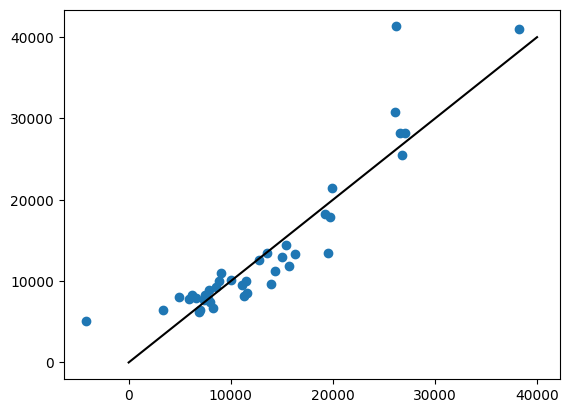

In [214]:
plt.scatter(bgd.predict(X_test), y_test)
# plt.scatter(sgd.predict(X_test), y_test)
plt.plot(np.linspace(0, 40000, 1000), np.linspace(0, 40000, 1000), color='black')
plt.show()

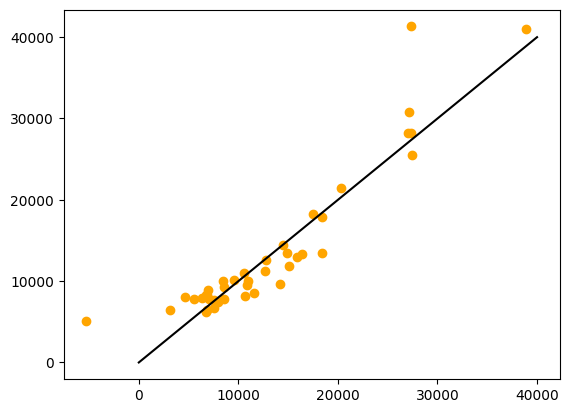

In [216]:
# plt.scatter(bgd.predict(X_test), y_test)
plt.scatter(sgd.predict(X_test), y_test, color='orange')
plt.plot(np.linspace(0, 40000, 1000), np.linspace(0, 40000, 1000), color='black')
plt.show()

In [221]:
bgd.score(X_train, y_train), bgd.score(X_test, y_test)

(np.float64(0.994583512695794), np.float64(0.8415617017615151))

# Regularization #

In [222]:
class Regularize_BatchGradientDescentL2:
    def __init__(self, lr=0.01, tol=0.001, max_iter=1000, alpha=0.01):
        self.lr = lr
        self.tol = tol
        self.max_iter = max_iter
        self.alpha = alpha  # regularization strength

        self.coef_ = None
        self.intercept_ = None
        self.lossi = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        rows = X.shape[0]

        X = np.c_[np.ones(rows), X]  # add bias term
        n_features = X.shape[1]

        coef = np.random.randn(n_features)  # includes intercept as coef[0]

        converged = False

        for i in range(self.max_iter):
            y_pred = X @ coef
            e = y - y_pred

            # Regularized Loss: RMSE + L2 penalty (for monitoring, not for stopping)
            loss = root_mse(y, y_pred) + self.alpha * np.sum(coef[1:] ** 2)
            self.lossi.append(loss)

            # Gradient of loss + L2 regularization (skip intercept at coef[0])
            grad = (-2 / rows) * X.T @ e
            grad[1:] += 2 * self.alpha * coef[1:]

            if np.linalg.norm(self.lr * grad) < self.tol:
                converged = True
                break

            coef -= self.lr * grad

        if not converged:
            print(f"Warning: Did not converge after {self.max_iter} steps.")

        self.coef_ = coef[1:]
        self.intercept_ = coef[0]
        self.step = i
        return self

    def predict(self, X):
        X = np.array(X)
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        y_pred = self.predict(X)
        return 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)


In [253]:
rbgd = Regularize_BatchGradientDescentL2(max_iter=100000, lr=0.01, tol=0.1, alpha=0.01)

rbgd.fit(X_train, y_train)

In [254]:
rbgd.score(X_train, y_train), rbgd.score(X_test, y_test)

(np.float64(0.9680306545359338), np.float64(0.8458011147636284))

In [255]:
bgd.score(X_test, y_test)

np.float64(0.8415617017615151)